### Baseline Model

The current model serves as a baseline for stock prediction.  
It uses the previous day's closing price as the only feature to predict the next day's price.

Feature used:

Prev_Close = Close.shift(1)

This means the model is essentially learning:

Close_today ≈ Close_yesterday

Because stock prices tend to move smoothly from day to day, the predicted values often closely track the actual values. This baseline helps establish a reference point that future models must outperform.

### TODO
- Implement a Ridge Regression model (alpha = 1)
- Standardize features before training
- Add additional lag features (Lag2, Lag3, Lag5)
- Add moving average features (MA5, MA20)
- Evaluate model improvements against the baseline

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv("../data/RBLX.csv", skiprows=2)

df.columns = ["Date","Close","High","Low","Open","Volume"]

df["Close"] = pd.to_numeric(df["Close"])

df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-10,69.500000,74.830002,60.500000,64.500000,97069300
1,2021-03-11,73.900002,77.779999,70.129997,74.930000,59629300
2,2021-03-12,69.699997,72.959999,69.110001,72.470001,19714700
3,2021-03-15,72.150002,74.059998,66.250000,70.019997,19549800
4,2021-03-16,77.000000,78.000000,73.180000,73.730003,30274400


In [32]:
df["Prev_Close"] = df["Close"].shift(1)

df = df.dropna()

df["Lag1"] = df["Close"].shift(1)
df["Lag2"] = df["Close"].shift(2)
df["Lag3"] = df["Close"].shift(3)
df["Lag5"] = df["Close"].shift(5)
df["MA5"] = df["Close"].rolling(5).mean()
df["MA20"] = df["Close"].rolling(20).mean()

df = df.dropna()

X = df[
    ["Lag1",
    "Lag2",
    "Lag3",
    "Lag5",
    "MA5",
    "MA20"]
    ]
y = df["Close"]

df.head()

,Date,Close,High,Low,Open,Volume,Prev_Close,Lag1,Lag2,Lag3,Lag5,MA5,MA20
82,2021-07-07,86.400002,89.348000,85.650002,87.849998,6153000,86.980003,86.980003,86.199997,85.820000,92.599998,87.076001,87.217001
83,2021-07-08,86.879997,88.050003,82.514999,83.279999,6729500,86.400002,86.400002,86.980003,86.199997,89.980003,86.456000,87.009000
84,2021-07-09,86.260002,87.300003,85.120003,87.290001,3936700,86.879997,86.879997,86.400002,86.980003,85.820000,86.544000,86.772001
85,2021-07-12,86.540001,89.870003,84.849998,87.099998,6762000,86.260002,86.260002,86.879997,86.400002,86.199997,86.612001,86.458001
86,2021-07-13,84.019997,86.449997,83.150002,86.339996,9196200,86.540001,86.540001,86.260002,86.879997,86.980003,86.020000,86.269000


In [33]:
model = joblib.load("../models/model.pkl")

preds = model.predict(X)

preds[:10]

array([86.95737264, 85.15147101, 86.19039067, 86.79828731, 84.43168335,
       81.30095175, 78.09404268, 78.67071888, 79.35937034, 78.33475418])

In [43]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

preds_test = model.predict(X_test)

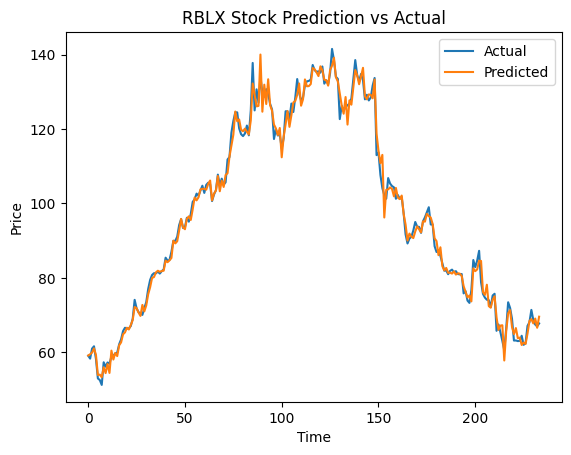

In [46]:
plt.figure()

plt.plot(y_test.values, label="Actual")
plt.plot(preds_test, label="Predicted")

plt.legend()
plt.title("RBLX Stock Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

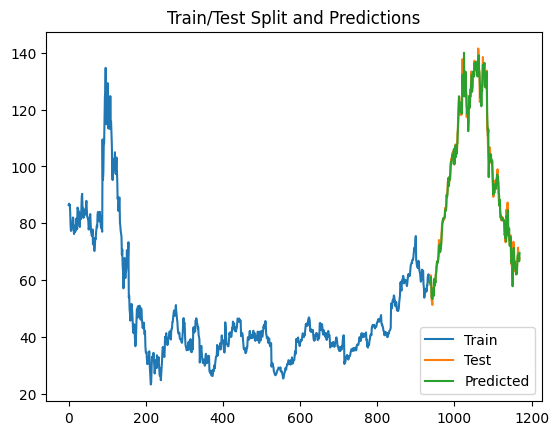

In [48]:
plt.figure()

plt.plot(range(len(y_train)), y_train, label="Train")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test")
plt.plot(range(len(y_train), len(y_train)+len(preds_test)), preds_test, label="Predicted")

plt.legend()
plt.title("Train/Test Split and Predictions")

plt.show()

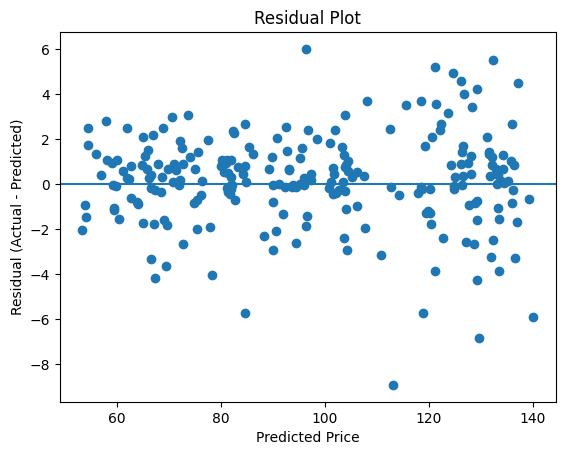

In [52]:
residuals = y_test.values - preds_test

plt.figure()

plt.scatter(preds_test, residuals)

plt.axhline(0)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")

plt.show()

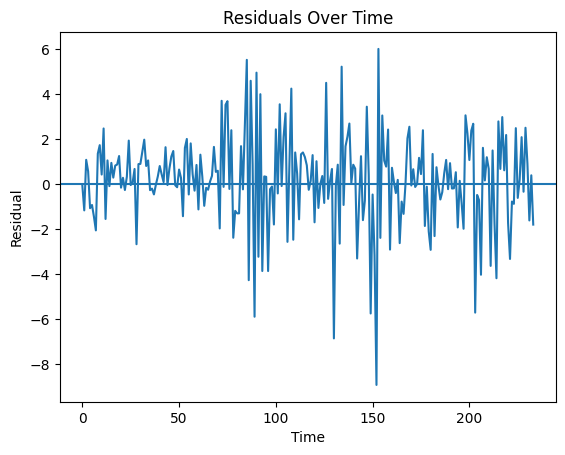

In [53]:
plt.figure()

plt.plot(residuals)

plt.axhline(0)

plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.show()